# Фичи изображений × зоны коры: что «решает» для каждой зоны

**Идея:** посчитать для каждой из 515 картинок набор интерпретируемых свойств
(сложность, симметрия, красочность, спектр, объектность...) и посмотреть, какие из них
предсказывают две пер-картиночные величины из ноутбука 04:

- **согласованность** — насколько одинаково зона представляет картинку у 8 испытуемых
  (чистая нейронаука, модель не участвует);
- **вклад** — насколько картинка несёт соответствие геометрий модель ↔ зона
  (Qwen2-VL на релевантной глубине).

**Осторожность в интерпретации:** фичи сильно скоррелированы между собой (сложные сцены
чаще содержат людей, и т.д.), поэтому смотрим и попарные корреляции Спирмена, и
совместную ridge-модель со стандартизованными коэффициентами, и матрицу фича×фича.


In [1]:
import io, json, sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image as PILImage

ROOT = Path.cwd() if (Path.cwd() / "cache").exists() else Path.cwd().parent
sys.path.insert(0, str(ROOT / "src"))

from scipy.spatial.distance import squareform
from scipy.stats import rankdata, spearmanr

from nsd_rsa.config import load_config, resolve_paths
from nsd_rsa.design import load_expdesign, usable_images
from nsd_rsa.loaders import average_repeats, common_valid_vertices, load_subject
from nsd_rsa.rdm import compute_rdm

cfg = load_config(str(ROOT / "configs" / "vlm.yaml"))
paths = resolve_paths(cfg)
design = load_expdesign(paths["meta"] / "nsd_expdesign.mat")
idx = usable_images(cfg["stimuli"]["subjects"], design, cfg["stimuli"]["min_repeats"])
valid = common_valid_vertices(paths["betas"], paths["cache"] / "valid_vertices.npy")

ROIS = ["early", "midventral", "ventral", "lateral"]
BRAIN = {}
for p in sorted(paths["betas"].glob("*_shared_betas.h5")):
    d = load_subject(p)
    for roi in ROIS:
        patt, _ = average_repeats(d, images=idx, roi=roi, valid=valid)
        BRAIN.setdefault(roi, {})[d.subject] = compute_rdm(patt.astype(np.float64))
    del d
SUBJECTS = sorted(BRAIN["early"])

IMAGES = np.load(paths["stimuli"] / "shared1000_images.npy", mmap_mode="r")[idx]
CATS = np.load(ROOT / "cache" / "coco_categories.npz")
ACTS = np.load(ROOT / "cache" / "f1_readouts_qwen2vl_2b.npz")
N = len(idx)
print(f"{N} картинок, {len(SUBJECTS)} испытуемых")

515 картинок, 8 испытуемых


## 1. Фичи изображений

| Фича | Что меряет |
|---|---|
| `jpeg_kb` | сложность как сжимаемость (размер JPEG q75) — классический прокси Колмогоровской сложности |
| `entropy` | энтропия гистограммы яркости |
| `edge_density` | доля пикселей-границ (Canny) |
| `sym_lr`, `sym_ud` | зеркальная симметрия (корреляция с отражением) |
| `colorfulness` | метрика Hasler–Süsstrunk |
| `spectral_slope` | наклон спада спектра мощности (статистика натуральных сцен, ~−2) |
| `hf_share` | доля энергии в верхней половине частот |
| `luminance`, `contrast` | яркость и RMS-контраст |
| `n_categories`, `area_covered` | сколько категорий COCO в кропе и какую долю площади покрывают объекты |
| `has_person`, `has_animal` | агенты в кадре |


In [2]:
from skimage.feature import canny

def image_features(im):
    g = im.mean(2)
    g01 = g / 255.0
    buf = io.BytesIO(); PILImage.fromarray(im).save(buf, "JPEG", quality=75)
    hist, _ = np.histogram(g, bins=256, range=(0, 255), density=True)
    hist = hist[hist > 0]
    # спектр
    f = np.abs(np.fft.rfft2(g01 - g01.mean()))**2
    fy = np.fft.fftfreq(g.shape[0])[:, None]; fx = np.fft.rfftfreq(g.shape[1])[None, :]
    rad = np.sqrt(fy**2 + fx**2).ravel(); pw = f.ravel()
    keep = (rad > 0.01) & (rad < 0.5)
    slope = np.polyfit(np.log(rad[keep]), np.log(pw[keep] + 1e-12), 1)[0]
    hf = pw[rad >= 0.25].sum() / (pw[keep].sum() + 1e-12)
    rg = im[:, :, 0].astype(float) - im[:, :, 1]
    yb = 0.5 * (im[:, :, 0].astype(float) + im[:, :, 1]) - im[:, :, 2]
    return {
        "jpeg_kb": buf.tell() / 1024,
        "entropy": float(-(hist * np.log2(hist)).sum()),
        "edge_density": float(canny(g01, sigma=2.0).mean()),
        "sym_lr": float(np.corrcoef(g.ravel(), g[:, ::-1].ravel())[0, 1]),
        "sym_ud": float(np.corrcoef(g.ravel(), g[::-1].ravel())[0, 1]),
        "colorfulness": float(np.sqrt(rg.std()**2 + yb.std()**2)
                              + 0.3 * np.sqrt(rg.mean()**2 + yb.mean()**2)),
        "spectral_slope": float(slope),
        "hf_share": float(hf),
        "luminance": float(g.mean()),
        "contrast": float(g.std()),
    }

cache_f = ROOT / "cache" / "image_features.csv"
if cache_f.exists():
    F = pd.read_csv(cache_f)
else:
    F = pd.DataFrame([image_features(np.asarray(IMAGES[i])) for i in range(N)])
    hot = CATS["multihot"]
    blob = json.loads((paths["meta"] / "coco" / "annotations" / "instances_val2017.json")
                      .read_text(encoding="utf-8"))
    id2name = {c["id"]: c["name"] for c in blob["categories"]}
    names = [id2name[c] for c in sorted(id2name)]
    animals = {"bird","cat","dog","horse","sheep","cow","elephant","bear","zebra","giraffe"}
    F["n_categories"] = hot.sum(1)
    F["area_covered"] = np.clip(CATS["area"].sum(1), 0, 1)
    F["has_person"] = hot[:, names.index("person")]
    F["has_animal"] = hot[:, [names.index(a) for a in animals]].max(1)
    F.to_csv(cache_f, index=False)
print(F.shape); F.describe().loc[["mean", "std", "min", "max"]].T.round(2)

(515, 14)


,mean,std,min,max
jpeg_kb,34.47,11.09,9.70,70.28
entropy,7.35,0.46,4.88,7.94
edge_density,0.06,0.03,0.00,0.15
sym_lr,0.29,0.27,-0.53,0.90
sym_ud,-0.02,0.27,-0.77,0.78
colorfulness,43.63,19.88,6.97,135.03
spectral_slope,-2.51,0.49,-3.94,-0.93
hf_share,0.09,0.06,0.01,0.54
luminance,117.96,28.63,45.88,218.92
contrast,57.68,13.48,14.67,102.55


## 2. Целевые величины (из ноутбука 04)

- `CONSIST[roi]` — средняя межсубъектная корреляция RDM-строки картинки;
- `CONTRIB[roi]` — вклад картинки в соответствие модель↔зона (Qwen2-VL, релевантная глубина).


In [3]:
def rank_sq(condensed):
    return squareform(rankdata(condensed))

CONSIST, CONTRIB = {}, {}
DEPTH = {"early": "vision.00.trim", "midventral": "vision.25.trim",
         "ventral": "vision.25.trim", "lateral": "llm.28.trim"}
for roi in ROIS:
    rows = np.stack([rank_sq(BRAIN[roi][s]) for s in SUBJECTS])
    rows = (rows - rows.mean(2, keepdims=True)) / (rows.std(2, keepdims=True) + 1e-12)
    sim = np.einsum("sij,tij->sti", rows, rows) / rows.shape[2]
    iu = np.triu_indices(len(SUBJECTS), 1)
    CONSIST[roi] = sim[iu].mean(0)

    m_sq = rank_sq(compute_rdm(ACTS[DEPTH[roi]].astype(np.float64)))
    b_sq = rank_sq(np.mean([BRAIN[roi][s] for s in SUBJECTS], axis=0))
    CONTRIB[roi] = ((m_sq - m_sq.mean()) * (b_sq - b_sq.mean())).sum(1)
print("targets ready")

targets ready


## 3. Что коррелирует с чем: Спирмен по всем парам фича × зона


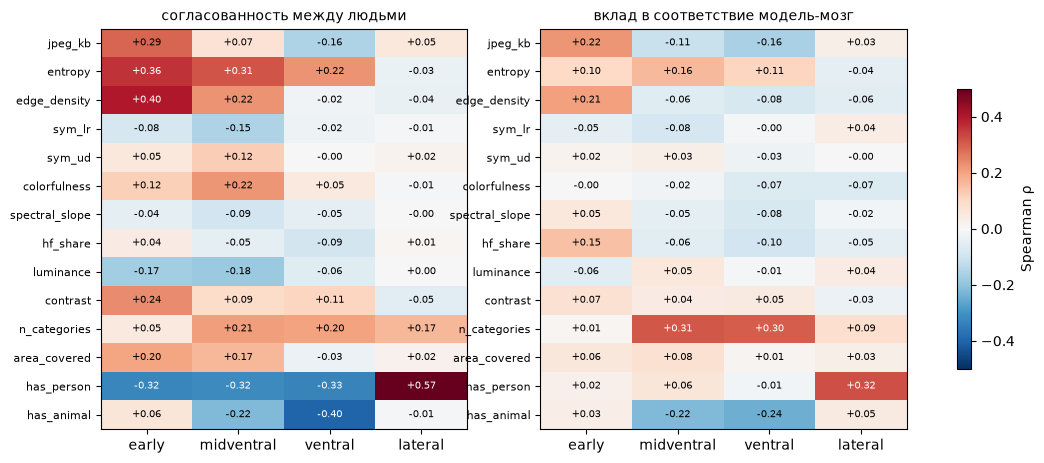

In [4]:
def corr_table(target):
    out = {}
    for roi in ROIS:
        out[roi] = {c: spearmanr(F[c], target[roi]).statistic for c in F.columns}
    return pd.DataFrame(out)

TC = corr_table(CONSIST)
TB = corr_table(CONTRIB)
fig, axes = plt.subplots(1, 2, figsize=(13, 5.2))
for ax, (t, name) in zip(axes, [(TC, "согласованность между людьми"),
                                (TB, "вклад в соответствие модель-мозг")]):
    im = ax.imshow(t.values, cmap="RdBu_r", vmin=-.5, vmax=.5, aspect="auto")
    ax.set_xticks(range(len(ROIS))); ax.set_xticklabels(ROIS)
    ax.set_yticks(range(len(t))); ax.set_yticklabels(t.index, fontsize=8)
    ax.set_title(name, fontsize=10)
    for i in range(t.shape[0]):
        for j in range(t.shape[1]):
            v = t.values[i, j]
            ax.text(j, i, f"{v:+.2f}", ha="center", va="center",
                    fontsize=7, color="w" if abs(v) > .3 else "k")
plt.colorbar(im, ax=axes, shrink=.7, label="Spearman ρ")
plt.show()

## 4. Совместная модель: стандартизованные ridge-коэффициенты

Попарные корреляции спутаны (см. §6). Ridge на всех фичах сразу показывает, что
остаётся у каждой фичи после учёта остальных, и сколько дисперсии цели объясняет всё
пространство фич (out-of-fold R²).


In [5]:
from sklearn.linear_model import RidgeCV
from sklearn.model_selection import cross_val_predict

X = (F - F.mean()) / (F.std() + 1e-12)
rows_r2, coefs = [], {}
for name, target in [("согласованность", CONSIST), ("вклад", CONTRIB)]:
    for roi in ROIS:
        y = (target[roi] - target[roi].mean()) / target[roi].std()
        m = RidgeCV(alphas=np.logspace(-2, 3, 12))
        pred = cross_val_predict(m, X, y, cv=5)
        rows_r2.append({"цель": name, "зона": roi,
                        "R² (5-fold)": 1 - ((y - pred)**2).sum() / (y**2).sum()})
        coefs[(name, roi)] = pd.Series(m.fit(X, y).coef_, index=F.columns)
pd.DataFrame(rows_r2).pivot_table(index="зона", columns="цель", values="R² (5-fold)").reindex(ROIS).round(3)

цель,вклад,согласованность
зона,,
early,0.003,0.232
midventral,0.081,0.361
ventral,0.081,0.495
lateral,0.017,0.367


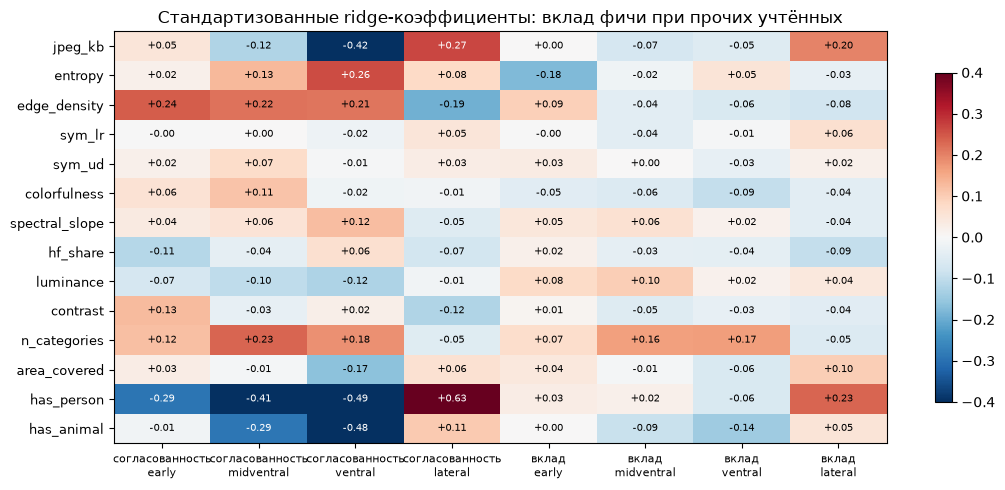

In [6]:
C = pd.DataFrame(coefs)
fig, ax = plt.subplots(figsize=(11, 5))
im = ax.imshow(C.values, cmap="RdBu_r", vmin=-.4, vmax=.4, aspect="auto")
ax.set_xticks(range(C.shape[1]))
ax.set_xticklabels([f"{a}\n{b}" for a, b in C.columns], fontsize=8)
ax.set_yticks(range(len(C))); ax.set_yticklabels(C.index, fontsize=9)
for i in range(C.shape[0]):
    for j in range(C.shape[1]):
        ax.text(j, i, f"{C.values[i,j]:+.2f}", ha="center", va="center", fontsize=7,
                color="w" if abs(C.values[i,j]) > .25 else "k")
ax.set_title("Стандартизованные ridge-коэффициенты: вклад фичи при прочих учтённых")
plt.colorbar(im, shrink=.8); plt.tight_layout(); plt.show()

## 5. Иллюстрации: крайние картинки по решающим фичам


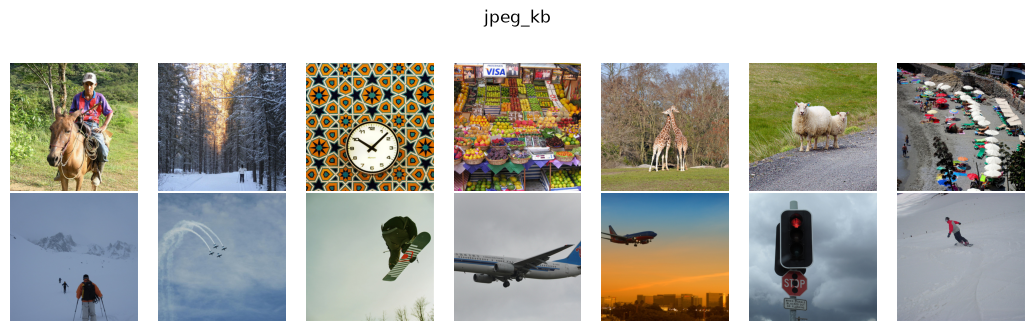

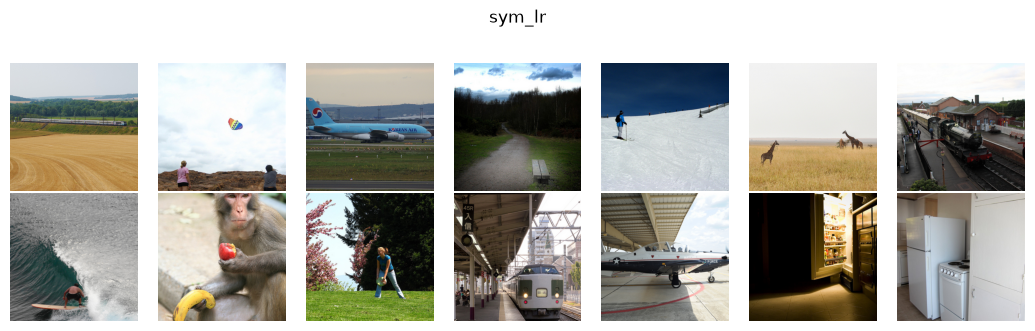

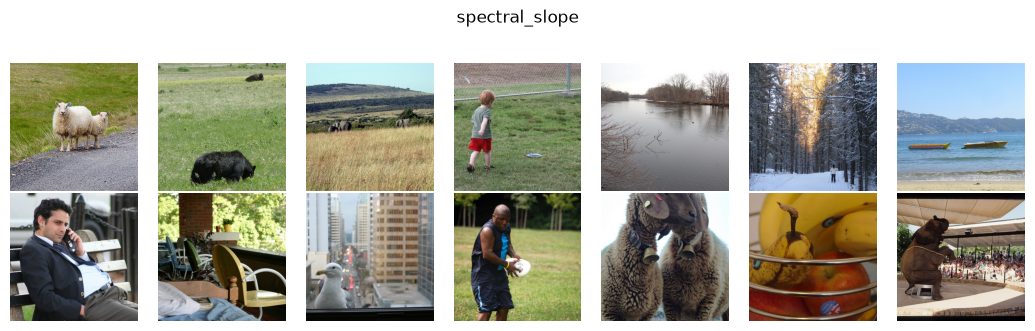

In [7]:
def show_extremes(feat, k=7):
    o = np.argsort(F[feat].values)
    fig, axes = plt.subplots(2, k, figsize=(k * 1.5, 3.2))
    for ax, i in zip(axes[0], o[::-1][:k]): ax.imshow(IMAGES[i]); ax.axis("off")
    for ax, i in zip(axes[1], o[:k]): ax.imshow(IMAGES[i]); ax.axis("off")
    axes[0][0].set_ylabel("max", fontsize=9); axes[1][0].set_ylabel("min", fontsize=9)
    fig.suptitle(feat, y=1.02); plt.tight_layout(); plt.show()

for feat in ["jpeg_kb", "sym_lr", "spectral_slope"]:
    show_extremes(feat)

## 6. Матрица фича × фича — почему нельзя читать попарные корреляции наивно


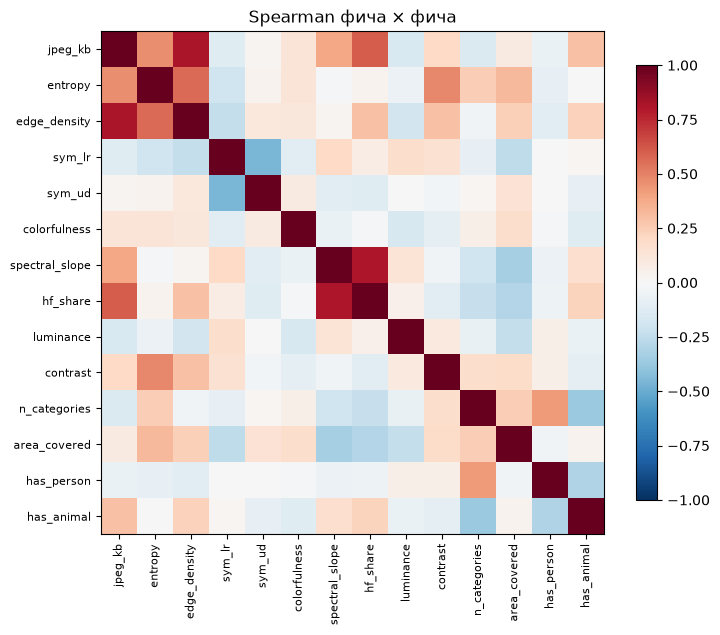

In [8]:
FC = F.corr(method="spearman")
fig, ax = plt.subplots(figsize=(7.5, 6.5))
im = ax.imshow(FC.values, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(FC))); ax.set_xticklabels(FC.columns, rotation=90, fontsize=8)
ax.set_yticks(range(len(FC))); ax.set_yticklabels(FC.index, fontsize=8)
plt.colorbar(im, shrink=.8); ax.set_title("Spearman фича × фича")
plt.tight_layout(); plt.show()

## Как это читать (заполняется после прогона — см. выводы выше)

Ожидаемые паттерны для проверки глазами:
- у `early` согласованность должна тянуться к низкоуровневым фичам (контраст, границы,
  спектр) — если это так, картина согласуется с частью А;
- у `lateral` — к агентным/объектным (has_person, n_categories), перекликаясь с
  ноутбуком 04;
- совместная модель покажет, что выживает после учёта корреляций между фичами, а R²
  скажет, какая доля пер-картиночной структуры вообще объяснима этим пространством фич.

Это исследовательский ноутбук: результаты идут в обсуждение/IDEAS, в препринт — только
если что-то окажется и сильным, и устойчивым.
